<a href="https://colab.research.google.com/github/guneetnagia/LearnML/blob/classification/classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install liac-arff

  Preparing metadata (setup.py) ... done
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=e63b2cd193cf50c9cf563c5018c3a891403de4cd8570bab3813ed4195042638b
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


In [6]:
import arff
import pandas as pd
from pathlib import Path

# Path to your file in Drive
arff_path = Path("/content/drive/MyDrive/colab/datasets/mnist_784.arff")

# Read ARFF file
with open(arff_path, 'r') as f:
    dataset = arff.load(f)

# Convert to pandas DataFrame
df = pd.DataFrame(dataset['data'], columns=[attr[0] for attr in dataset['attributes']])

✅ MNIST loaded from Google Drive successfully
X shape: (70000, 784)
y shape: (70000,)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [9]:
# Separate features and labels
X = df.drop('class', axis=1).to_numpy()
y = df['class'].astype(str).to_numpy()

print("✅ MNIST loaded from Google Drive successfully")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("X is:", X)
print("y is:", y)

✅ MNIST loaded from Google Drive successfully
X shape: (70000, 784)
y shape: (70000,)
X is: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
y is: ['5' '0' '4' ... '4' '5' '6']


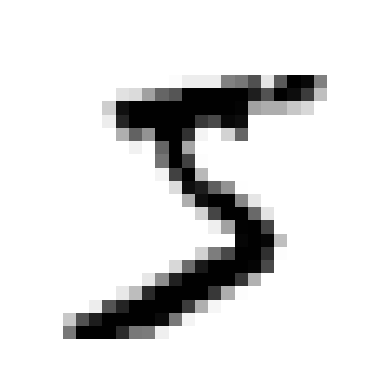

In [10]:
# view one digit
import matplotlib.pyplot as plt
def plot_image(image_data):
  image = image_data.reshape(28,28)
  plt.imshow(image, cmap="binary")
  plt.axis("off")

some_digit = X[0]
plot_image(some_digit)
plt.show()

# looks like 5, but we can with y[0]

In [11]:
y[0]

'5'

[ True]


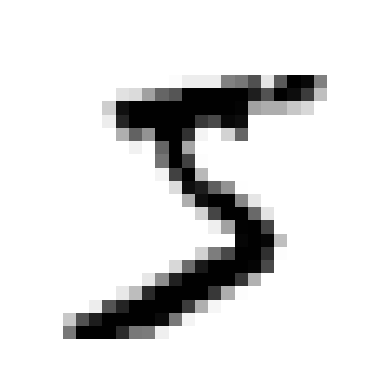

In [13]:
from sklearn.linear_model import SGDClassifier
# Let's run binary classifier, which will classify whether it is same or not. Like whether image is number 5 or not

# Split data
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Create binary labels: True if the digit is '5'
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

# Train the classifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

# Pick one image to test
some_digit = X[0]
prediction = sgd_clf.predict([some_digit])

print(prediction)  # Output: [True] or [False]

# Optional: show the image
def plot_image(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

plot_image(some_digit)
plt.show()

In [14]:
# measure accuracy - k fold cross validation
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")


array([0.95035, 0.96035, 0.9604 ])

In [15]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train))) # print false: no 5s detected

cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

# only 90%, hence accuracy is not preffered performance measure for skewed dataset

False


array([0.90965, 0.90965, 0.90965])